# Credit Grab - Explaining Model Decisions

![](https://live.staticflickr.com/65535/54368714616_e90a2c644c_z.jpg)

*Image generated by ChatGPT.*

## Introduction
Imagine you are a data analyst at a company that assesses credit risk.
Your team has developed a model that makes decisions about granting credit to customers
based on key financial indicators.
The model works efficiently, but a problem has arisen -
customers who have been refused credit are demanding specific explanations.

Company management is aware that saying "the computer decided so"
is not sufficient. They need something more - concrete guidance for customers
about what they could change in their financial situation to receive a positive credit decision.

As a machine learning specialist, you are asked to develop a system
that will help understand model decisions and show customers a path to obtaining credit.


## Task
Fortunately, to better understand the problem and develop a solution, you will work on a simplified,
two-dimensional dataset. This will allow visualization of results and a better understanding of how
your explanation system works.

Your task is to propose a *method for generating explanations* for rejected credit applications that will propose realistic changes in financial indicator values and ultimately lead to a positive decision by the classifier - a neural network.

While working on the solution, you will be able to see the results in charts that will show:
- The initial position of the observations to be explained;
- The classifier's decision boundary;
- Proposed changes in the form of vectors and final explanation proposals;
- The estimated density distribution of training data, which will help assess the realism of the proposed changes.

### Data
The data available to you in this task are:
- Training dataset;
- Dataset to be explained;
- A discriminative model trained on the training data; this model is what you will explain;
- A generative model used to estimate the density of the training data distribution.

In particular, your method for generating explanations may only use the discriminative model, the generative model, and the data to be explained. The training data serves only to better illustrate the task's objective.

Your solution will ultimately be tested on the Competition Platform on a hidden test dataset, which includes new training data, data to be explained, and a discriminative and generative model. The characteristics of the test data will not differ significantly from the dataset provided for building the solution. Additionally, validation data will be available to you on the Competition Platform, where you can ensure that the entire solution executes correctly.

### Evaluation Criteria
As you might expect, the evaluation will assess three key aspects of your solution:
1. **Effectiveness of Decision Change** - whether your proposals actually lead to credit approval;
2. **Realism of Explanations** - whether they lie in an area similar to the training data, i.e., whether they are achievable for customers;
3. **Distance of Explanations** - whether the proposed modifications are as small as possible, so as not to burden the customer with excessive changes in their financial situation.

Because customer satisfaction matters, each of these aspects must exceed a certain threshold for you to receive points for it. Additionally, each will influence the final score of your solution, according to the formulas presented below, and your final result will be in the range $[0, 100]$.

The solution evaluation is based on three main metrics:

**Effectiveness of Decision Change ($V$)** - A measure determining the percentage of generated explanations that effectively change the classifier's decision:

$$V = \begin{cases}
0, & \text{if } validity < 0.50 \\
\frac{validity - 0.50}{1.00 - 0.50}, & \text{if } 0.50 \leq validity \leq 1.00 \\
1, & \text{if } validity > 1.00
\end{cases}$$

where *validity* is defined as follows:
$$\text{validity} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}[f(\mathbf{{x'}_i}) > 0.5],$$
where $\mathbf{{x'}_i}$ is the proposed explanation for observation $i$, $f$ is the discriminative model, and $N$ is the number of observations.

**Realism of Explanations ($P$)** - A measure determining the percentage of generated explanations that are considered realistic:

$$P = \begin{cases}
0, & \text{if } plausibility < 0.50 \\
\frac{plausibility - 0.50}{1.00 - 0.50}, & \text{if } 0.50 \leq plausibility \leq 1.00 \\
1, & \text{if } plausibility > 1.00
\end{cases}$$

where *plausibility* is defined as follows:
$$\text{plausibility} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}[\log{P(\mathbf{{x'}_i}|y')} \geq \text{log\_prob\_threshold}],$$
where $\log{P(\mathbf{{x'}_i}|y')}$ is the logarithm of the probability of the proposed $i$-th explanation $\mathbf{{x'}_i}$ given the target class $y'$ - this is the result of the `forward` function of the `gen_model` generative model. And $\text{log\_prob\_threshold}$ is the log-probability threshold that the proposed explanation must exceed and was previously determined based on the training data.

**Distance of Explanations ($D$)** - A measure determining how much the proposed changes differ from the customer's original data:

$$D = \begin{cases} 
1, & \text{if } \text{L2 distance} < 0.22 \\
\frac{0.30 - \text{L2 distance}}{0.30 - 0.22}, & \text{if } 0.22 \leq \text{L2 distance} \leq 0.30 \\
0, & \text{if } \text{L2 distance} > 0.30.
\end{cases}$$

**Final Score Formula**
The final score is a combination of the above metrics according to the formula:

$$S = 100 \cdot V \cdot \left(\frac{D}{2} + \frac{P}{2}\right)$$

This formula expresses that the Effectiveness of Decision Change ($V$) is multiplied by the Distance of Explanations ($D$) and the Realism of Explanations ($P$). This means that to achieve a good result, the solution must be effective in changing the classifier's decision, while proposing changes that are both realistic and efficient (minimal). The final score $S$ is in the range $[0, 100]$, where:
- Values close to $0$ indicate a poor solution;
- Values close to $100$ indicate an excellent solution that effectively changes the classifier's decisions while maintaining realism and minimal changes.

## Limitations
- Your solution will be tested on the Competition Platform without internet access.
- Evaluation of your final solution on the Competition Platform cannot take longer than 2 minutes.
- Your solution cannot use the training set, i.e., `X_train`, `y_train`.
- Available libraries: Matplotlib, Numpy, Pandas, PyTorch, Scikit-Learn

## Notes and Tips
- It is worth changing the loss function to achieve better results.
- It is worth using the provided generative model to estimate the density of the training data distribution.

## Submission Files
This notebook supplemented with your solution (see the `your_generate_explanations` function).

## Evaluation
Remember that during checking, the `FINAL_EVALUATION_MODE` flag will be set to `True`.

You can earn between 0 and 100 points for this task. The number of points you will receive will be calculated on the (secret) test set on the Competition Platform based on the above formula, rounded to an integer. If your solution does not meet the above criteria or does not execute correctly, you will receive 0 points for the task.


# Starter Code
In this section, we initialize the environment by importing the necessary libraries and functions. The prepared code will help you operate efficiently on data and build an appropriate solution.

In [1]:
######################### DO NOT CHANGE THIS CELL ##########################

FINAL_EVALUATION_MODE = False  # During checking, this flag will be set to True.

In [2]:
######################### DO NOT CHANGE THIS CELL ##########################
# Import libraries
import os

from typing import List, Union

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from sklearn.inspection import DecisionBoundaryDisplay


In [3]:
######################### DO NOT CHANGE THIS CELL ##########################
# Code reproducibility

RANDOM_SEED = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
######################### DO NOT CHANGE THIS CELL ##########################
# Cell containing model class definitions.

## Multilayer Perceptron ##

class MultilayerPerceptron(torch.nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_layer_sizes: List[int],
        target_size: int,
        dropout: float = 0.2,
    ):
        super(MultilayerPerceptron, self).__init__()
        self.target_size = target_size
        self.input_size = input_size
        layer_sizes = [input_size] + hidden_layer_sizes + [target_size]
        self.layers = torch.nn.ModuleList()
        for i in range(len(layer_sizes) - 1):
            self.layers.append(torch.nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(dropout)
        self.target_size = target_size
        if target_size == 1:
            self.final_activation = torch.nn.Sigmoid()
            self.criterion = torch.nn.BCEWithLogitsLoss()
            self.prep_for_loss = lambda x: x.view(-1, 1).float()
        else:
            self.final_activation = torch.nn.Softmax(dim=1)
            self.criterion = torch.nn.CrossEntropyLoss()
            self.prep_for_loss = lambda x: x.view(-1).long()

    def forward(self, x):
        for i in range(len(self.layers)):
            if i == len(self.layers) - 1:
                x = self.layers[i](x)
            else:
                x = self.relu(self.layers[i](x))
        return x

    def fit(
        self,
        train_loader: torch.utils.data.DataLoader,
        test_loader: torch.utils.data.DataLoader = None,
        epochs: int = 200,
        lr: float = 0.001,
        patience: int = 20,
        eps: float = 1e-3,
        checkpoint_path: str = "best_model.pth",
    ):
        min_test_loss = float("inf")
        optimizer = torch.optim.RAdam(self.parameters(), lr=lr)
        for epoch in range(epochs):
            train_loss = 0
            test_loss = 0
            for i, (examples, labels) in enumerate(train_loader):
                optimizer.zero_grad()
                outputs = self.forward(examples)
                loss = self.criterion(outputs, self.prep_for_loss(labels))
                train_loss += loss.item()
                loss.backward()
                optimizer.step()
            train_loss /= len(train_loader)
            if test_loader:
                with torch.no_grad():
                    for i, (examples, labels) in enumerate(test_loader):
                        outputs = self.forward(examples)
                        loss = self.criterion(outputs, self.prep_for_loss(labels))
                        test_loss += loss.item()
                        # Early stopping
                    test_loss /= len(test_loader)
                if test_loss < (min_test_loss - eps):
                    min_test_loss = test_loss
                    patience_counter = 0
                    self.save(checkpoint_path)
                else:
                    patience_counter += 1
                if patience_counter > patience:
                    break
                self.load(checkpoint_path)
            print(
                f"Epoch {epoch}, Train: {train_loss:.4f}, test: {test_loss:.4f}, patience: {patience_counter}"
            )

    def predict(self, X_test: Union[np.ndarray, torch.Tensor]):
        if isinstance(X_test, np.ndarray):
            X_test = torch.from_numpy(X_test).float()
        with torch.no_grad():
            probs = self.predict_proba(X_test) > 0.5
            return probs.squeeze().float()

    def predict_proba(self, X_test: Union[np.ndarray, torch.Tensor]):
        if isinstance(X_test, np.ndarray):
            X_test = torch.from_numpy(X_test).float()
        with torch.no_grad():
            logits = self.forward(X_test)
            probs = self.final_activation(logits)
            return probs.float()

    def save(self, path: str):
        torch.save(self.state_dict(), path)

    def load(self, path: str):
        self.load_state_dict(torch.load(path))


## Kernel Density Estimator ##

class GaussianKernel(nn.Module):
    """Implementation of the Gaussian kernel."""
    
    def __init__(self, bandwidth=1.0):
        """Initializes a new Kernel.

        Args:
            bandwidth: The kernel's (band)width.
        """
        super().__init__()
        self.bandwidth = bandwidth

    def _diffs(self, test_Xs, train_Xs):
        """Computes difference between each x in test_Xs with all train_Xs."""
        test_Xs = test_Xs.view(test_Xs.shape[0], 1, *test_Xs.shape[1:])
        train_Xs = train_Xs.view(1, train_Xs.shape[0], *train_Xs.shape[1:])
        return test_Xs - train_Xs

    def forward(self, test_Xs, train_Xs):
        """Computes log p(x) for each x in test_Xs given train_Xs."""
        n, d = train_Xs.shape
        n, h = torch.tensor(n, dtype=torch.float32), torch.tensor(self.bandwidth)
        pi = torch.tensor(np.pi)

        Z = 0.5 * d * torch.log(2 * pi) + d * torch.log(h) + torch.log(n)
        diffs = self._diffs(test_Xs, train_Xs) / h
        log_exp = -0.5 * torch.norm(diffs, p=2, dim=-1) ** 2

        return torch.logsumexp(log_exp - Z, dim=-1)

    @torch.no_grad()
    def sample(self, train_Xs):
        """Generates samples from the kernel distribution."""
        device = train_Xs.device
        noise = torch.randn(train_Xs.shape, device=device) * self.bandwidth
        return train_Xs + noise


class KernelDensityEstimator(nn.Module):
    """The KernelDensityEstimator model."""

    def __init__(self, train_Xs, kernel=None):
        """Initializes a new KernelDensityEstimator.

        Args:
            train_Xs: The "training" data to use when estimating probabilities.
            kernel: The kernel to place on each of the train_Xs.
        """
        super().__init__()
        self.kernel = kernel or GaussianKernel()
        self.train_Xs = nn.Parameter(train_Xs, requires_grad=False)
        assert len(self.train_Xs.shape) == 2, "Input cannot have more than two axes."

    def __call__(self, x, *args, **kwargs):
        """Saves input tensor attributes so they can be accessed during sampling."""
        if getattr(self, "_c", None) is None and x.dim() == 4:
            _, c, h, w = x.shape
            self._create_shape_buffers(c, h, w)
        return super().__call__(x, *args, **kwargs)

    def load_state_dict(self, state_dict, strict=True):
        """Registers dynamic buffers before loading the model state."""
        if "_c" in state_dict and not getattr(self, "_c", None):
            c, h, w = state_dict["_c"], state_dict["_h"], state_dict["_w"]
            self._create_shape_buffers(c, h, w)
        super().load_state_dict(state_dict, strict)

    def _create_shape_buffers(self, channels, height, width):
        channels = channels if torch.is_tensor(channels) else torch.tensor(channels)
        height = height if torch.is_tensor(height) else torch.tensor(height)
        width = width if torch.is_tensor(width) else torch.tensor(width)
        self.register_buffer("_c", channels)
        self.register_buffer("_h", height)
        self.register_buffer("_w", width)

    @property
    def device(self):
        return self.train_Xs.device

    def forward(self, x):
        return self.kernel(x, self.train_Xs)

    @torch.no_grad()
    def sample(self, n_samples):
        idxs = np.random.choice(range(len(self.train_Xs)), size=n_samples)
        return self.kernel.sample(self.train_Xs[idxs])


class KDE(torch.nn.Module):
    def __init__(self, bandwidth=0.1, **kwargs):  # Ignores kwargs!
        super(KDE, self).__init__()
        self.bandwidth = bandwidth
        self.models = nn.ModuleDict()

    def _context_to_key(self, context):
        return str(int(context))

    def _get_model_for_context(self, context):
        key = self._context_to_key(context)
        if key not in self.models:
            raise ValueError(f"Context {key} not found in the model.")
        return self.models[key]

    def load_state_dict(
            self,
            state_dict,
            strict: bool = True,
            assign: bool = False,
    ):
        for key in state_dict.keys():
            if key.startswith("models."):
                self.models[key.split(".")[1]] = KernelDensityEstimator(
                    state_dict[key], kernel=GaussianKernel(bandwidth=self.bandwidth)
                )
        return super().load_state_dict(state_dict, strict, assign)

    def fit(
            self,
            train_loader: torch.utils.data.DataLoader,
            test_loader: torch.utils.data.DataLoader,
            checkpoint_path: str = "best_model.pth",
            **kwargs,
    ):
        train_Xs, train_ys = train_loader.dataset.tensors
        train_ys = train_ys.view(-1)
        for y in train_ys.unique():
            idxs = train_ys == y
            self.models.update(
                {
                    self._context_to_key(y.item()): KernelDensityEstimator(
                        train_Xs[idxs], kernel=GaussianKernel(bandwidth=self.bandwidth)
                    )
                }
            )
        self.save(checkpoint_path)

        train_log_probs = self.predict_log_prob(train_loader)
        test_log_probs = self.predict_log_prob(test_loader)
        print(f"Train log-likelihood: {train_log_probs.float().mean()}")
        print(f"Test log-likelihood: {test_log_probs.float().mean()}")

    def forward(self, x: torch.Tensor, context: torch.Tensor):
        preds = torch.zeros_like(context)
        for i in range(x.shape[0]):
            model = self._get_model_for_context(context[i].item())
            preds[i] = model(x[i].unsqueeze(0))
        return preds.view(-1)

    def predict_log_prob(self, dataloader: torch.utils.data.DataLoader):
        inputs, context = dataloader.dataset.tensors
        preds = self(inputs, context)
        preds = torch.zeros_like(context, dtype=torch.float32)
        for i in range(inputs.shape[0]):
            model = self._get_model_for_context(context[i].item())
            preds[i] = model(inputs[i].unsqueeze(0))
        return preds

    def save(self, path):
        torch.save(self.state_dict(), path)

    def load(self, path):
        self.load_state_dict(torch.load(path))


In [5]:
######################### DO NOT CHANGE THIS CELL ##########################
# Cell containing helper functions for drawing plots.

## HELPER FUNCTIONS ##

def _plot_generative_model_distribution(ax, model, log_prob_threshold=None):
    xline = torch.linspace(-0, 1, 200)
    yline = torch.linspace(-0, 1, 200)
    xgrid, ygrid = torch.meshgrid(xline, yline)
    xyinput = torch.cat([xgrid.reshape(-1, 1), ygrid.reshape(-1, 1)], dim=1)

    with torch.no_grad():
        zgrid = model(xyinput, torch.ones(40000, 1)).exp().reshape(200, 200)
        zgrid = zgrid.numpy()
        _ = ax.contour(
            xgrid.numpy(),
            ygrid.numpy(),
            zgrid,
            levels=10,
            cmap="Greys",
            linewidths=0.4,
            antialiased=True,
        )
        ax.plot([], [], color='grey', alpha=0.3, label="Training data density contours")

    if log_prob_threshold is not None:
        prob_threshold_exp = np.exp(log_prob_threshold)
        _ = ax.contourf(
            xgrid.numpy(),
            ygrid.numpy(),
            zgrid,
            levels=[prob_threshold_exp, prob_threshold_exp * 10.00],
            alpha=0.1,
            colors="#DC143C",
        )  # 10.00 is an arbitrary huge value to colour the whole distribution.
        ax.plot([], [], color='#DC143C', alpha=0.3, label="Realistic explanation area")

    return ax


def _plot_classifier_decision_region(ax, model):
    xline = torch.linspace(0, 1, 1000)
    yline = torch.linspace(0, 1, 1000)
    xgrid, ygrid = torch.meshgrid(xline, yline, indexing="ij")
    xyinput = torch.cat([xgrid.reshape(-1, 1), ygrid.reshape(-1, 1)], dim=1)

    y_hat = model.predict(xyinput)
    y_hat = y_hat.reshape(1000, 1000)

    display = DecisionBoundaryDisplay(xx0=xgrid, xx1=ygrid, response=y_hat)
    display.plot(plot_method="contour", ax=ax, alpha=0.3)
    ax.plot([], [], color='green', alpha=0.3, label="Model decision boundary")
    return ax


def _plot_propositions(ax, propositions):
    ax.scatter(
        propositions[:, 0], 
        propositions[:, 1], 
        c="orange", 
        s=50, 
        alpha=0.8,
        label="Explanations"
    )
    return ax


def _plot_observations(ax, observations, targets):
    indices = targets == 0

    observations_0 = observations[indices]
    observations_1 = observations[~indices]
    
    ax.scatter(
        observations_0[:, 0],
        observations_0[:, 1],
        c="blue",
        s=50,
        alpha=0.8,
        label="Observations from class 0"
    )

    ax.scatter(
        observations_1[:, 0],
        observations_1[:, 1],
        c="red",
        s=50,
        alpha=0.8,
        label="Observations from class 1"
    )
    return ax


def _plot_observations_to_explain(ax, observations):
    ax.scatter(
        observations[:, 0],
        observations[:, 1],
        c="blue",
        s=50,
        alpha=0.8,
        label="Observations to explain"
    )
    return ax


def _plot_arrows(ax, observations, propositions):
    for i in range(len(observations)):
        ax.arrow(
            observations[i, 0],
            observations[i, 1],
            propositions[i, 0] - observations[i, 0],
            propositions[i, 1] - observations[i, 1],
            width=0.001,
            lw=0.001,
            length_includes_head=True,
            alpha=0.5,
            color="k",
        )
    return ax


def plot_initial_setup(X_orig, y_orig, disc_model=None, gen_model=None, log_prob_threshold=None):
    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(20, 12)

    ax = _plot_observations(ax, X_orig, y_orig)

    if disc_model:
        ax = _plot_classifier_decision_region(ax, disc_model)
    if gen_model:
        ax = _plot_generative_model_distribution(
            ax, gen_model, log_prob_threshold=log_prob_threshold
        )

    ax.legend(loc="lower left")
    return fig, ax


def plot_explanation_setup(X_orig, X_new=None, disc_model=None, gen_model=None, log_prob_threshold=None):
    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(20, 12)

    ax = _plot_observations_to_explain(ax, X_orig)
    
    if disc_model:
        ax = _plot_classifier_decision_region(ax, disc_model)
    
    if gen_model:
        ax = _plot_generative_model_distribution(
            ax, gen_model, log_prob_threshold=log_prob_threshold
        )
    
    if X_new is not None:
        assert (
                X_orig.shape == X_new.shape
        ), f"Sizes of test set and counterfactuals are not equal. Actual sizes: X_orig: {X_orig.shape}, X_cf: {X_new.shape}"

        ax = _plot_propositions(ax, X_new)
        ax = _plot_arrows(ax, X_orig, X_new)
    
    ax.legend(loc="lower left")
    return fig, ax


In [6]:
######################### DO NOT CHANGE THIS CELL ##########################

# Definition of paths to datasets and models
DATA_DIRECTORY = 'data'

ARRAY_X_TRAIN_PATH = f'{DATA_DIRECTORY}/x_train.npy'
ARRAY_X_EXPLAIN_PATH = f'{DATA_DIRECTORY}/x_explain.npy'
ARRAY_Y_TRAIN_PATH = f'{DATA_DIRECTORY}/y_train.npy'

DISC_MODEL_PATH = f'{DATA_DIRECTORY}/disc_model.pth'
GEN_MODEL_PATH = f'{DATA_DIRECTORY}/gen_model.pth'
LOG_PROB_THRESHOLD_PATH = f'{DATA_DIRECTORY}/log_prob_threshold.txt'


## Loading Data
In this part of the task, we will load the training data that was used to train the discriminative model.

In [7]:
######################### DO NOT CHANGE THIS CELL ##########################

X_train = np.load(ARRAY_X_TRAIN_PATH)
y_train = np.load(ARRAY_Y_TRAIN_PATH)

Display the training data.

C:\Users\raian\AppData\Local\Temp\ipykernel_21048\699111919.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


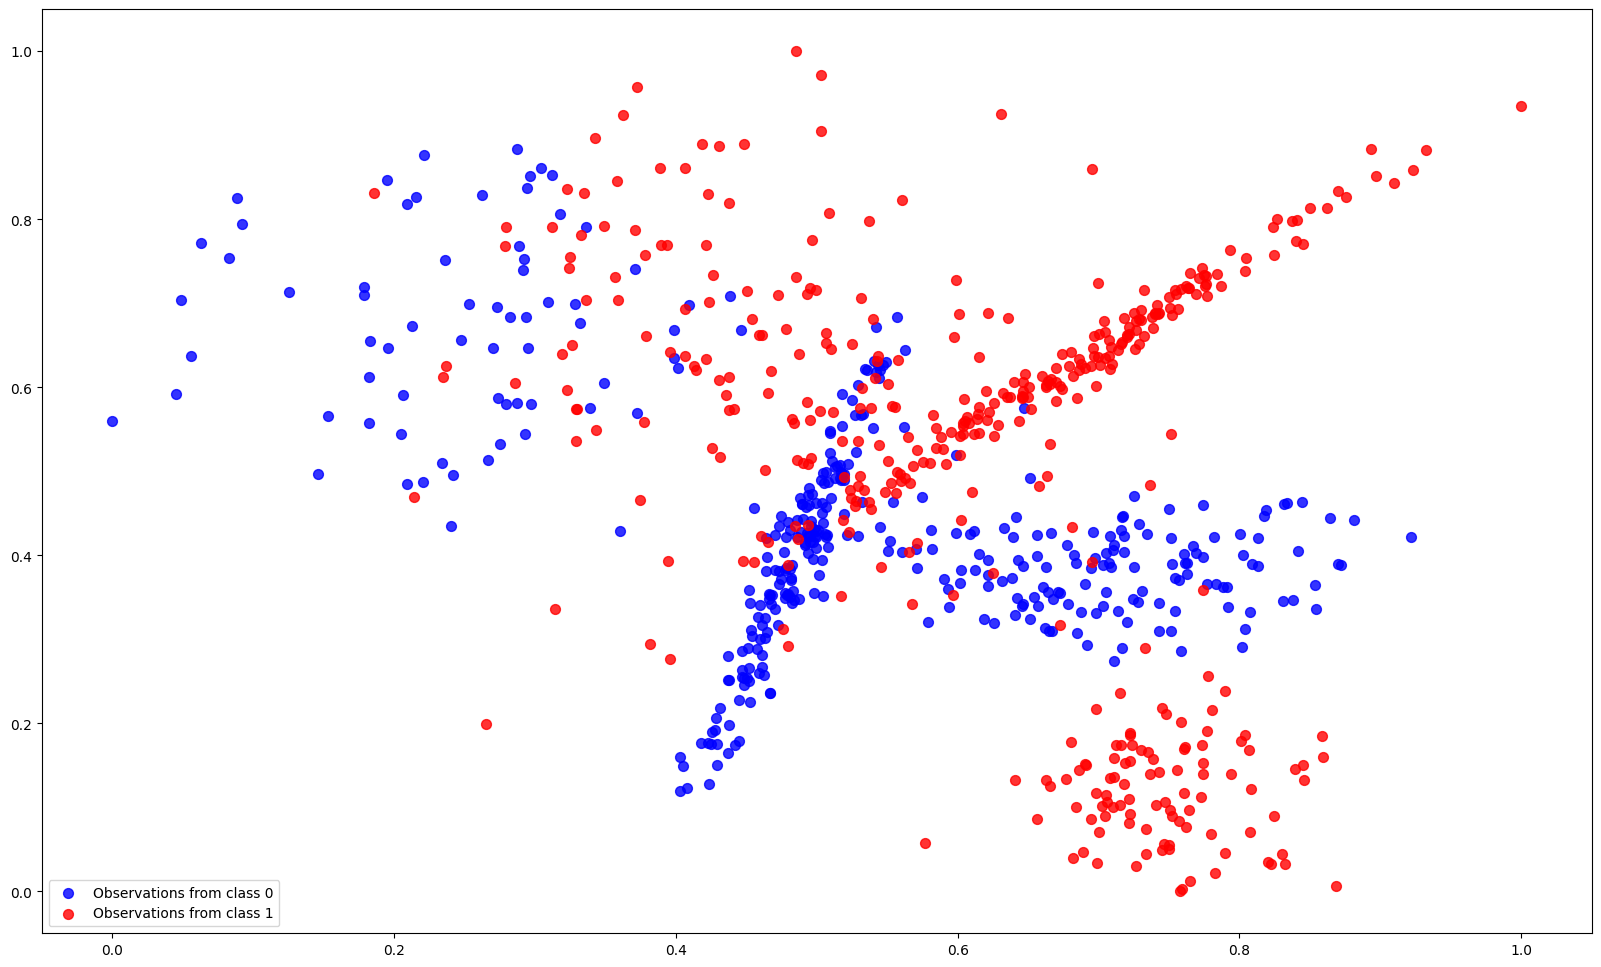

In [8]:
######################### DO NOT CHANGE THIS CELL ##########################

if not FINAL_EVALUATION_MODE:
    fig, ax = plot_initial_setup(X_train, y_train)
    fig.show()

## Loading the Discriminative Model

In this task, we will explain a simple neural network model that was previously trained.

In [9]:
######################### DO NOT CHANGE THIS CELL ##########################

disc_model = MultilayerPerceptron(
    input_size=2, 
    hidden_layer_sizes=[256, 256], 
    target_size=1, 
    dropout=0.1
)
disc_model.load(DISC_MODEL_PATH)
disc_model.eval()

MultilayerPerceptron(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
  (final_activation): Sigmoid()
  (criterion): BCEWithLogitsLoss()
)

Display the dataset and the model's decision boundaries.

C:\Users\raian\AppData\Local\Temp\ipykernel_21048\1177687098.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


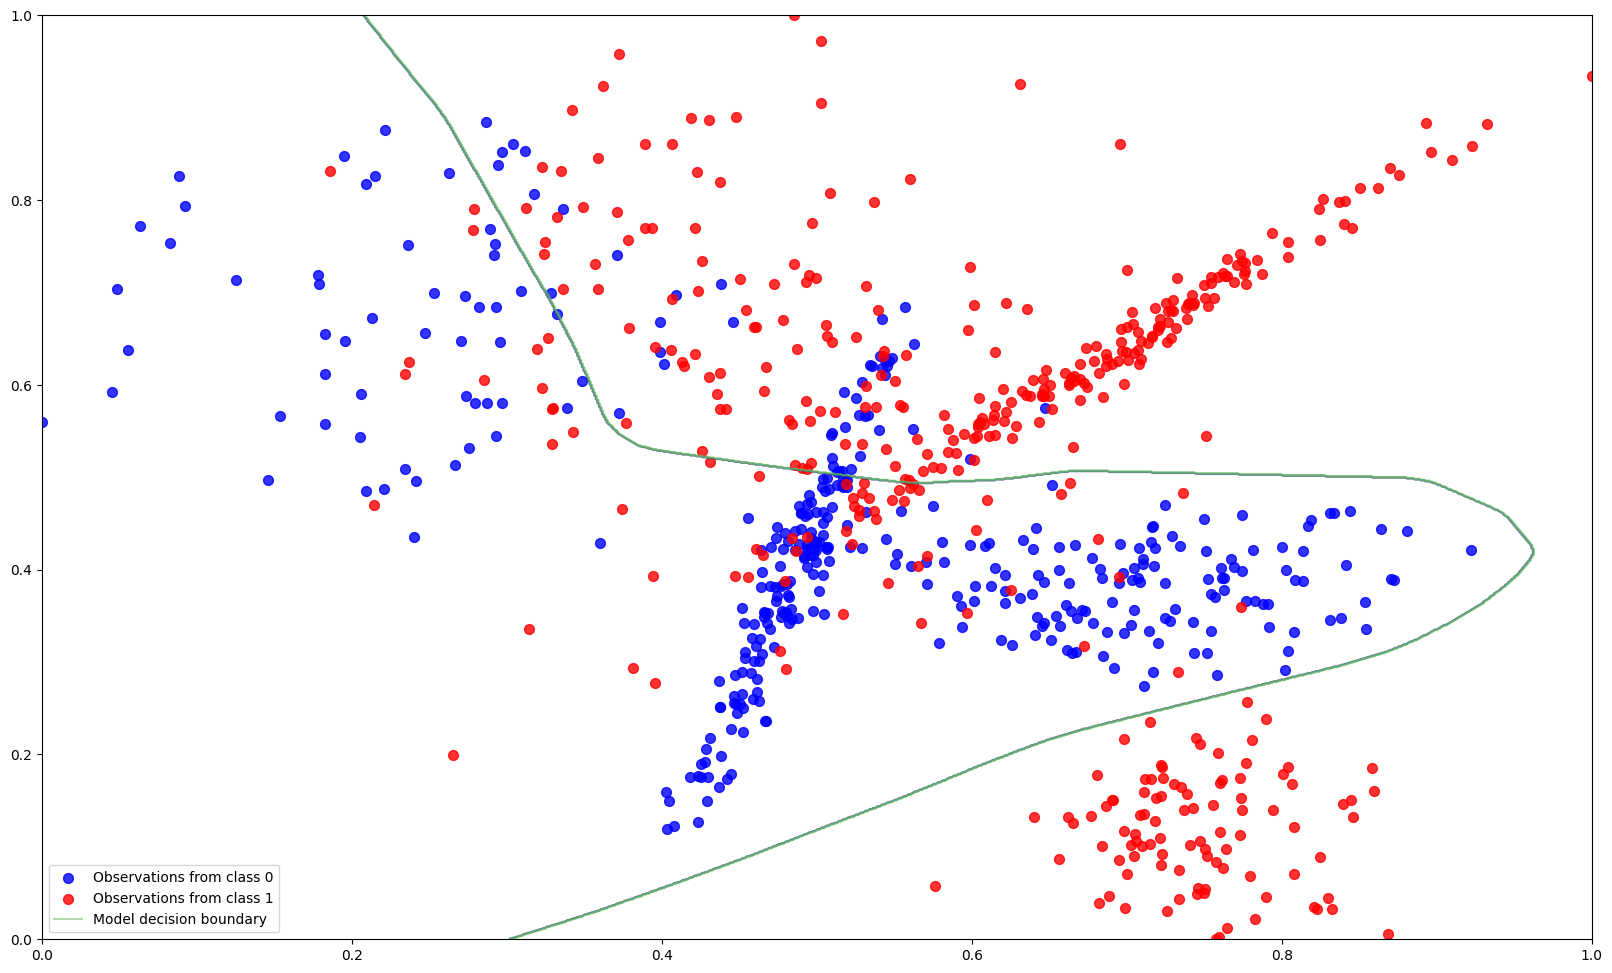

In [10]:
######################### DO NOT CHANGE THIS CELL ##########################

if not FINAL_EVALUATION_MODE:
    fig, ax = plot_initial_setup(X_train, y_train, disc_model=disc_model)
    fig.show()

## Realism of Explanations

In this task, we focus on an important aspect of generating explanations - we want the generated points to be realistic, and in our case, we will define that as originating from an area of high density in the training data distribution.
   
Let's start by exploring the topic of density estimation. Density estimation is the task of finding a function $p(x)$ that approximates the true probability distribution of the data $p^*(x)$. Formally, given a set of samples ${x_1, ..., x_n}$ originating from an unknown distribution $p^*(x)$, we want to find a model $p(x)$ that best approximates this distribution.

In this task, we will use a Kernel Density Estimation (KDE) model, which is one of the most popular density estimation models. As the acceptability threshold for realism, we will use the median of the density function values for the training points, which has been pre-calculated for you. This means that the KDE density function for the proposed new variables for the customer should have a value above the acceptability threshold. This concept is visualized in the next plot as the red area.


## Loading the Generative Model along with the Acceptability Threshold

In [11]:
######################### DO NOT CHANGE THIS CELL ##########################

gen_model = KDE(bandwidth=0.05)
gen_model.load(GEN_MODEL_PATH)
gen_model.eval()

with open(LOG_PROB_THRESHOLD_PATH, 'r') as f:
    log_prob_threshold = float(f.read())


Display the model setup, data, and data density distribution

c:\Users\raian\source\repos\AI\.env\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
C:\Users\raian\AppData\Local\Temp\ipykernel_21048\117766966.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


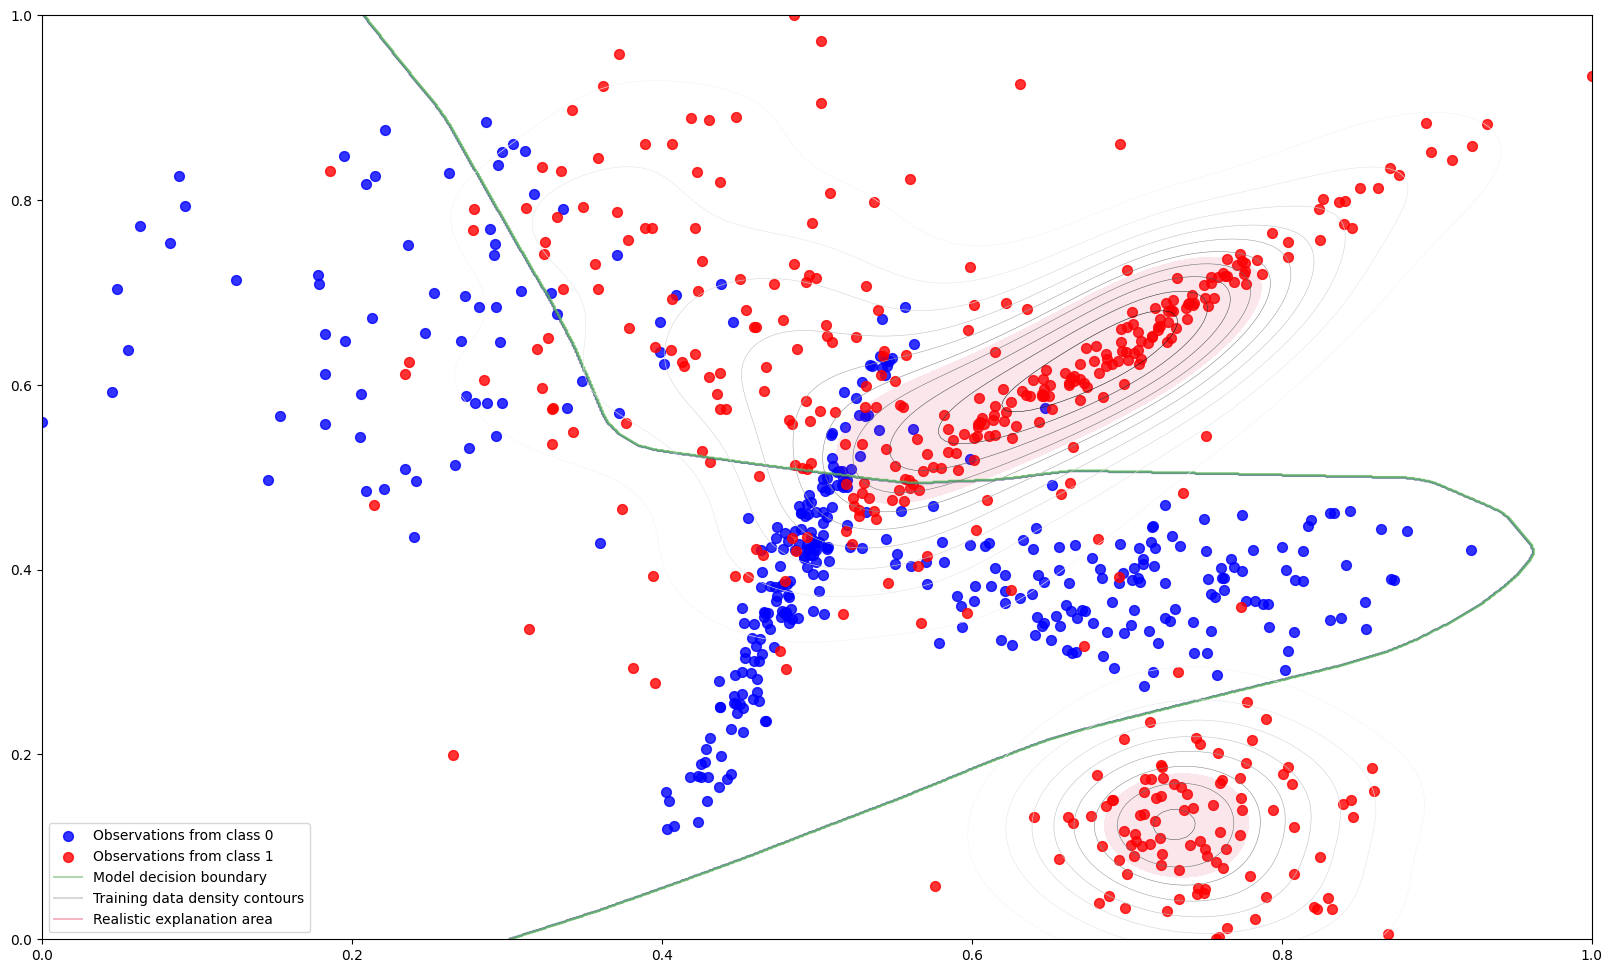

In [12]:
######################### DO NOT CHANGE THIS CELL ##########################

if not FINAL_EVALUATION_MODE:
    fig, ax = plot_initial_setup(
        X_train,
        y_train,
        disc_model=disc_model,
        gen_model=gen_model,
        log_prob_threshold=log_prob_threshold
    )
    fig.show()

## Loading Data to Explain
In this part of the task, we will load the dataset to be explained. Your task will be to generate explanations for points from this dataset.


In [13]:
######################### DO NOT CHANGE THIS CELL ##########################

X_explain = np.load(ARRAY_X_EXPLAIN_PATH)
y_explain = np.ones((X_explain.shape[0], 1))  # Vector of 1 - the target class to change the model's decision to

C:\Users\raian\AppData\Local\Temp\ipykernel_21048\1395160249.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


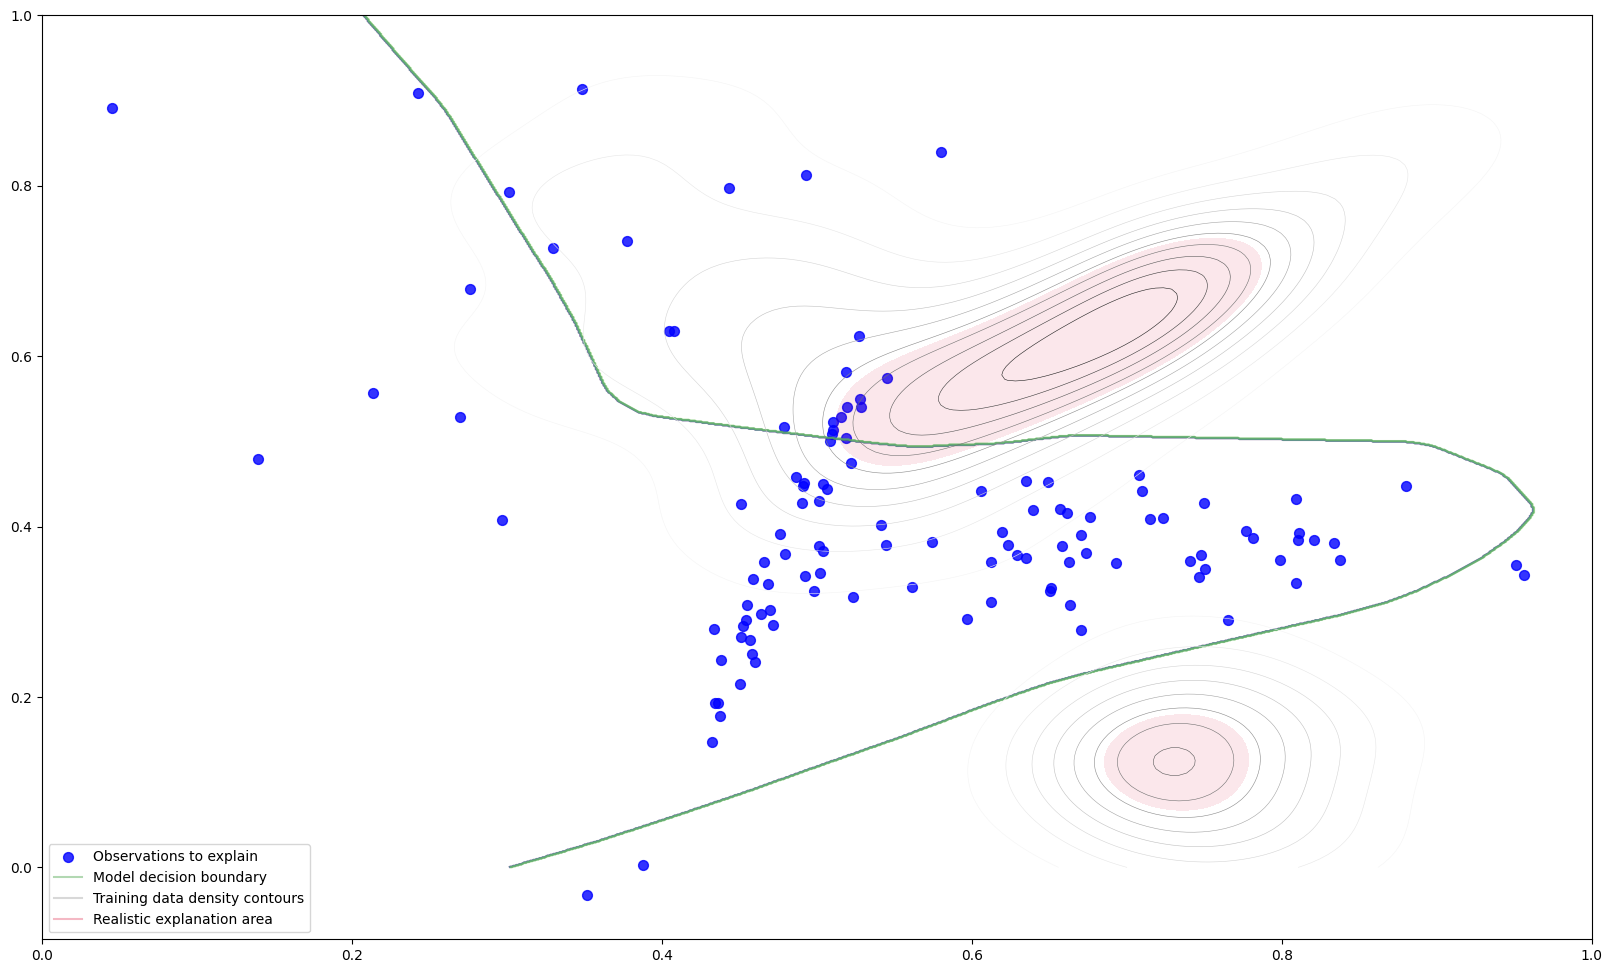

In [14]:
######################### DO NOT CHANGE THIS CELL ##########################

if not FINAL_EVALUATION_MODE:
    fig, ax = plot_explanation_setup(X_explain, disc_model=disc_model, gen_model=gen_model, log_prob_threshold=log_prob_threshold)
    fig.show()

## Example Solution
Below we present a simplified solution that serves as an example demonstrating the basic functionality of the notebook. It can serve as a starting point for developing your solution.

One way to solve the above problem is the method of optimizing the target point $x^*$ by minimizing the following objective function:

$$ L(x^*) = \text{BCE}(f(x^*), y^*) + \lambda \cdot |x^* - x|^2_2 $$

where:
- $\text{BCE}$ is the binary cross-entropy loss function
- $f(x^*)$ is the model's prediction for point $x^*$
- $y^*$ is the desired target class
- $|x^* - x|_2^2$ is the squared Euclidean distance between point x* and the original point x
- $\lambda$ is the regularization parameter for the trade-off between loss components (in implementation $\lambda$=0.1)

This is a basic approach that does not take into account the training data distribution. Below you will find an example implementation.

In [15]:
######################### DO NOT CHANGE THIS CELL ##########################

def example_generate_explanations(
        X_explain: np.ndarray, 
        y_explain: np.ndarray, 
        disc_model: MultilayerPerceptron,
        gen_model: KDE,
        log_prob_threshold: float,
        verbose: bool = False
    ) -> np.ndarray:
    
    num_steps: int = 1000
    lr: float = 0.01

    x_orig = torch.tensor(X_explain, dtype=torch.float32)
    target = torch.tensor(y_explain, dtype=torch.float32)

    # Definition of new points X as explanations.
    x_new = torch.tensor(X_explain, requires_grad=True)
    
    optimizer = torch.optim.Adam([x_new], lr=lr)
    bce_loss = torch.nn.BCEWithLogitsLoss(reduction='none')

    for _ in range(num_steps):
        optimizer.zero_grad()

        # Prediction Loss (Binary Cross Entropy)
        pred = disc_model(x_new)
        pred_loss = bce_loss(pred, target)

        # Distance Loss (Squared L2)
        dist_loss = torch.sum((x_orig - x_new)**2, axis=1, keepdim=True)

        # Total Loss
        total_loss = pred_loss + 0.1 * dist_loss
        total_loss = total_loss.mean()

        if verbose:
            print(f"Total loss: {total_loss:.4f}")

        total_loss.backward()
        optimizer.step()
            
    return x_new.detach().numpy()

if not FINAL_EVALUATION_MODE:
    X_new = example_generate_explanations(X_explain, y_explain, disc_model=disc_model, gen_model=gen_model, log_prob_threshold=log_prob_threshold)

## Visualization of Explanations

C:\Users\raian\AppData\Local\Temp\ipykernel_21048\4044767279.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


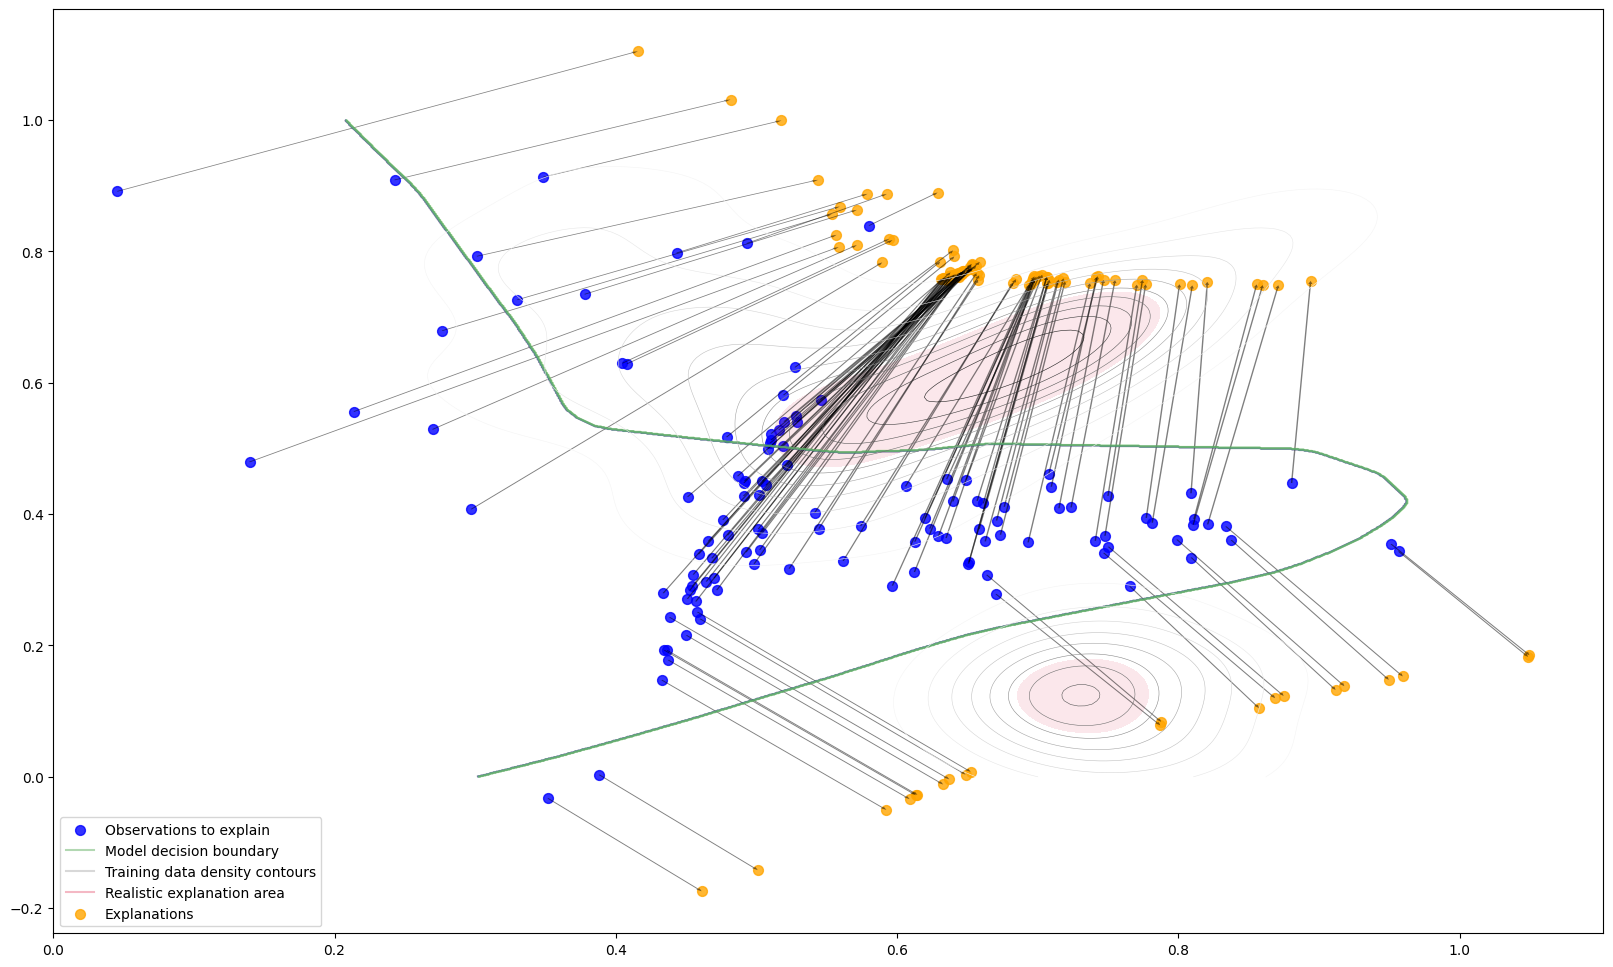

In [16]:
######################### DO NOT CHANGE THIS CELL ##########################

# Visualization of generated explanations
if not FINAL_EVALUATION_MODE:
    fig, ax = plot_explanation_setup(
        X_explain,
        X_new=X_new,
        disc_model=disc_model,
        gen_model=gen_model,
        log_prob_threshold=log_prob_threshold
    )
    fig.show()

# Your Solution
In this section, you should place your solution. Make changes only here!

Your task is to implement the `your_generate_explanations` function.
Remember that the function definition should not be changed, and the resulting array of results should be the same size as the input array of points to be explained.

In [ ]:
def your_generate_explanations(
        X_explain: np.ndarray, 
        y_explain: np.ndarray, 
        disc_model: MultilayerPerceptron,
        gen_model: KDE,
        log_prob_threshold: float
    ) -> np.ndarray:

    LR = 1e-2
    STEPS = 5000
    kde_class = gen_model.models['1']

    x_new = torch.tensor(X_explain.copy(), dtype=torch.float32, requires_grad=True)
    optim = torch.optim.Adam(x_new, lr=LR)
    criterion = torch.nn.BCEWithLogitsLoss()

    for _ in range(STEPS):
        out = disc_model(x_new)

        optim.zero_grad()
        loss_func = criterion(out, y_explain)
        loss_penalty = torch.sum((X_explain - x_new)**2, dim=1, keepdim=True)

        log_probs = kde_class(x_new)
        loss_plausibility = torch.clamp(log_prob_threshold - log_probs, min=0).unsqueeze(1)
        loss = loss_func + 0.5 * (loss_penalty + loss_plausibility)
        loss.backward()
        optim.step()

        with torch.no_grad():
            x_new.clamp(0,1)


    return x_new.numpy()

# Evaluation

Running the cell below will allow you to check how many points your solution would score on the available data. Before submitting, make sure that the entire notebook executes from beginning to end without errors and without requiring user intervention after selecting the "Run All" option.

In [19]:
######################### DO NOT CHANGE THIS CELL ##########################

def scale(x, lower=0.50, upper=1.00, max_points=1.0):
    """Function to linearly scale the result."""
    scaled = min(max(x, lower), upper)
    return (scaled - lower) / (upper - lower) * max_points


def calculate_average_distance(X_orig, X_new):
    """Calculate the average L2 distance between points."""
    distances = np.sqrt(np.sum((X_orig - X_new)**2, axis=1))
    return np.mean(distances)


def calculate_validity_criterion(disc_model, X_new):
    """Calculate the percentage of observations that correctly cross the decision boundary."""    
    with torch.no_grad():
        cf_preds = disc_model.predict(X_new)
    return np.mean((cf_preds > 0.5).numpy())


def calculate_plausibility_criterion(gen_model, X_new, log_prob_threshold):
    """Calculate the percentage of observations above the realism threshold."""
    with torch.no_grad():
        cf_log_probs = gen_model(torch.tensor(X_new, dtype=torch.float32), torch.ones((X_new.shape[0], 1)))
        return torch.mean((cf_log_probs >= log_prob_threshold).float()).item()


def calculate_final_metric(X_explain, X_new, disc_model, gen_model, verbose=True):
    """Calculate the final metric."""
    LOG_PROB_THRESHOLD = log_prob_threshold
    DISTANCE_UPPER_BOUND = 0.30
    DISTANCE_LOWER_BOUND = 0.22
    VALIDITY_UPPER_BOUND = 1.00
    VALIDITY_LOWER_BOUND = 0.50
    PLAUSIBILITY_UPPER_BOUND = 1.00
    PLAUSIBILITY_LOWER_BOUND = 0.50
    
    avg_distance = calculate_average_distance(X_explain, X_new)
    distances = 1 if avg_distance < DISTANCE_LOWER_BOUND else max(0, min(1, (DISTANCE_UPPER_BOUND - avg_distance) / (DISTANCE_UPPER_BOUND - DISTANCE_LOWER_BOUND)))

    validity_rate = calculate_validity_criterion(disc_model, X_new)
    validity_rate = scale(validity_rate, VALIDITY_LOWER_BOUND, VALIDITY_UPPER_BOUND)
    
    plausibility_rate = calculate_plausibility_criterion(gen_model, X_new, LOG_PROB_THRESHOLD)
    plausibility_rate = scale(plausibility_rate, PLAUSIBILITY_LOWER_BOUND, PLAUSIBILITY_UPPER_BOUND)

    if verbose:
        print(f"Average distance: {avg_distance:.4f}\n")
        print(f"Score: Explanation distance: {distances:.4f}")
        print(f"Score: Classifier decision change effectiveness: {validity_rate:.4f}")
        print(f"Score: Explanation realism effectiveness: {plausibility_rate:.4f}")
        print("-"*30)
    
    # Calculate final metric
    score = 100 * validity_rate * (plausibility_rate + distances) / 2
    final_metric = int(round(score))
    print(f"Estimated points for the task: {final_metric}")
    return final_metric


if not FINAL_EVALUATION_MODE:
    X_new = your_generate_explanations(X_explain, y_explain, disc_model=disc_model, gen_model=gen_model, log_prob_threshold=log_prob_threshold)
    final_score = calculate_final_metric(X_explain, X_new, disc_model, gen_model)


Average distance: 0.0000

Score: Explanation distance: 1.0000
Score: Classifier decision change effectiveness: 0.0000
Score: Explanation realism effectiveness: 0.0000
------------------------------
Estimated points for the task: 0


During checking, the model will be saved as `your_model.pkl` and evaluated on the validation and test sets.

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

if FINAL_EVALUATION_MODE:
    import cloudpickle

    OUTPUT_PATH = "file_output"
    FUNCTION_FILENAME = "your_model.pkl"
    FUNCTION_OUTPUT_PATH = os.path.join(OUTPUT_PATH, FUNCTION_FILENAME)

    if not os.path.exists(OUTPUT_PATH):
        os.makedirs(OUTPUT_PATH)

    with open(FUNCTION_OUTPUT_PATH, "wb") as f:
        cloudpickle.dump(your_generate_explanations, f)
